In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("US_Healthcare_Data_.xlsx",sheet_name="US_Healthcare_dataset")

In [4]:
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Am0unt,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Jamie Clark,57,F,AB+,Obesity,2020-06-23,Amanda Walker,Alexander-Tran,UnitedHealthcare,20504.824770,103,Elective,2020-07-08,Lipitor,Abnormal
1,Carrie Davis,71,F,O-,Hypertension,2022-10-01,Todd Edwards,Moody PLC,UnitedHealthcare,34346.445610,104,Urgent,2022-10-05,Aspirin,Inconclusive
2,Tiffany Vaughan,36,M,B-,Obesity,2021-04-30,Gary Price,"Smith, Gonzalez and Anderson",Medicare,9488.485422,106,Elective,2021-05-05,Lipitor,Normal
3,Dorothy Ingram,74,M,O-,Obesity,2022-04-21,Samantha Byrd,Cross-Rosales,Medicare,24378.849370,101,Elective,2022-05-04,Paracetamol,Inconclusive
4,Pamela Chavez,25,F,O+,Asthma,2020-05-10,Robert Wilkerson,"Calderon, Bonilla and Allison",Aetna,19459.674960,105,Urgent,2020-06-03,Ibuprofen,Normal


In [6]:
df.shape

(10000, 15)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                10000 non-null  object        
 1   Age                 10000 non-null  int64         
 2   Gender              10000 non-null  object        
 3   Blood Type          10000 non-null  object        
 4   Medical Condition   10000 non-null  object        
 5   Date of Admission   10000 non-null  datetime64[ns]
 6   Doctor              10000 non-null  object        
 7   Hospital            10000 non-null  object        
 8   Insurance Provider  10000 non-null  object        
 9    Billing Am0unt     10000 non-null  float64       
 10  Room Number         10000 non-null  int64         
 11  Admission Type      10000 non-null  object        
 12  Discharge Date      10000 non-null  datetime64[ns]
 13  Medication          10000 non-null  object     

In [10]:
df.describe()

,Age,Date of Admission,Billing Am0unt,Room Number,Discharge Date
count,10000.000000,10000,10000.000000,10000.000000,10000
mean,51.452200,2021-05-02 16:07:14.880000,23381.114016,300.082000,2021-05-16 11:42:17.280000
min,18.000000,2018-10-30 00:00:00,371.750501,101.000000,2018-11-01 00:00:00
25%,35.000000,2020-02-11 00:00:00,10825.162022,199.000000,2020-02-23 18:00:00
50%,52.000000,2021-05-03 00:00:00,20280.000000,299.000000,2021-05-16 00:00:00
75%,68.000000,2022-07-23 06:00:00,32350.334190,400.000000,2022-08-05 00:00:00
max,85.000000,2023-10-30 00:00:00,79932.796160,500.000000,2023-11-27 00:00:00
std,19.588974,NaN,16383.009916,115.806027,NaN


In [11]:
df.columns = df.columns.str.strip()

In [12]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Am0unt', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [14]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [15]:
df['Length of Stay'] = (
    df['Discharge Date'] - df['Date of Admission']).dt.days

In [18]:
df.head(3)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Am0unt,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Jamie Clark,57,F,AB+,Obesity,2020-06-23,Amanda Walker,Alexander-Tran,UnitedHealthcare,20504.824770,103,Elective,2020-07-08,Lipitor,Abnormal,15
1,Carrie Davis,71,F,O-,Hypertension,2022-10-01,Todd Edwards,Moody PLC,UnitedHealthcare,34346.445610,104,Urgent,2022-10-05,Aspirin,Inconclusive,4
2,Tiffany Vaughan,36,M,B-,Obesity,2021-04-30,Gary Price,"Smith, Gonzalez and Anderson",Medicare,9488.485422,106,Elective,2021-05-05,Lipitor,Normal,5


In [19]:
total_patients = len(df)

print(total_patients)

10000


In [20]:
avg_age = df['Age'].mean()

print(avg_age)

51.4522


In [21]:
total_revenue = df['Billing Am0unt'].sum()

print(total_revenue)

233811140.16475332


In [22]:
avg_bill = df['Billing Am0unt'].mean()

print(avg_bill)

23381.11401647533


In [23]:
avg_stay = df['Length of Stay'].mean()

print(avg_stay)

13.816


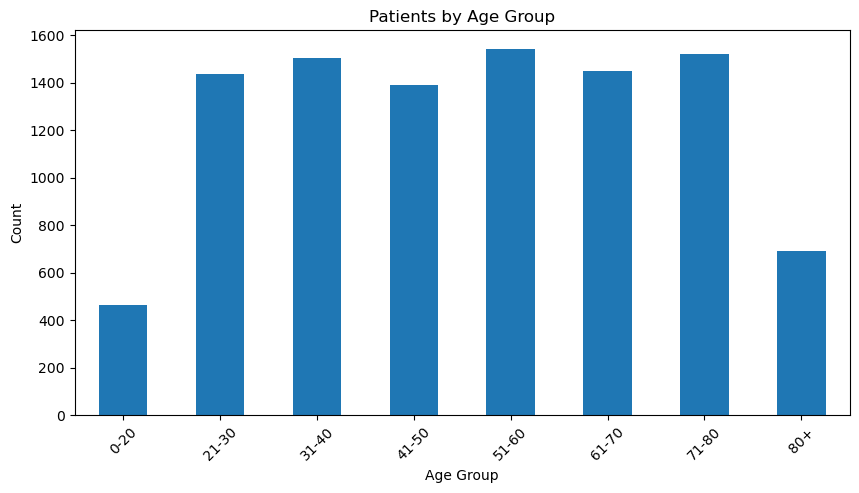

In [52]:
bins = [0, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ['0-20','21-30','31-40','41-50','51-60','61-70','71-80','80+']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df['Age Group'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [53]:
# Insight: The most common patients are generally aged between 51-80 

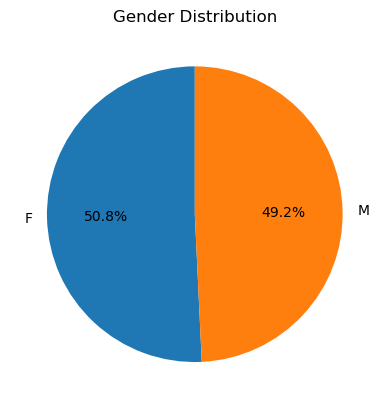

In [30]:
gender_counts = df['Gender'].value_counts()

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution")
plt.show()

In [54]:
# Insight: There is not that much difference in gender but males are slightly more than females

In [31]:
condition_counts = (
    df['Medical Condition']
    .value_counts()
)

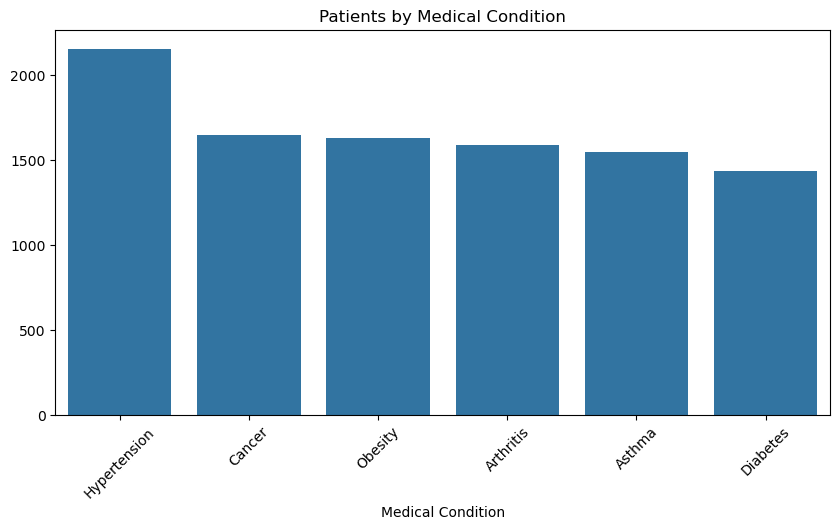

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=condition_counts.index,
    y=condition_counts.values
)

plt.xticks(rotation=45)
plt.title("Patients by Medical Condition")

plt.show()

In [55]:
# Insight: Hypertension is the most common disease.

In [33]:
condition_revenue = ( df.groupby('Medical Condition')['Billing Am0unt'].sum().sort_values(ascending=False))

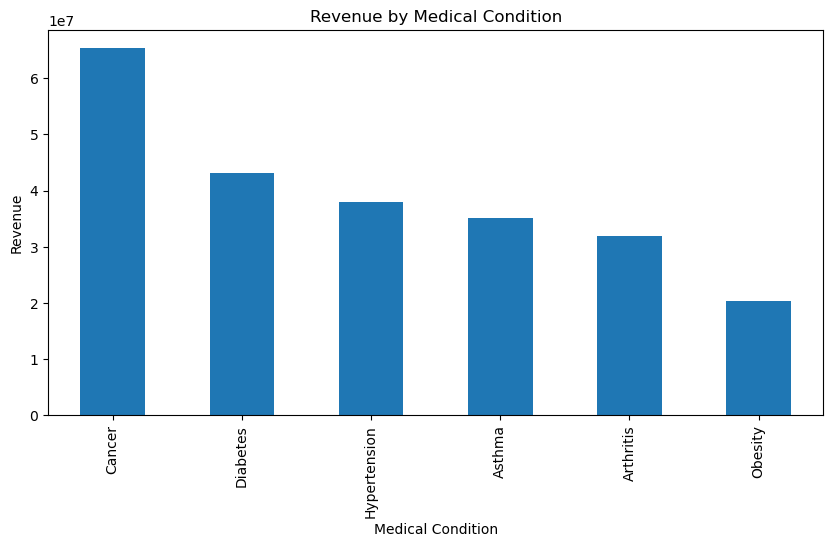

In [34]:
plt.figure(figsize=(10,5))

condition_revenue.plot(kind='bar')

plt.title("Revenue by Medical Condition")
plt.ylabel("Revenue")

plt.show()

In [56]:
# Insight: Cancer condition contributes the most billing revenue

In [35]:
insurance = (
    df['Insurance Provider'].value_counts())

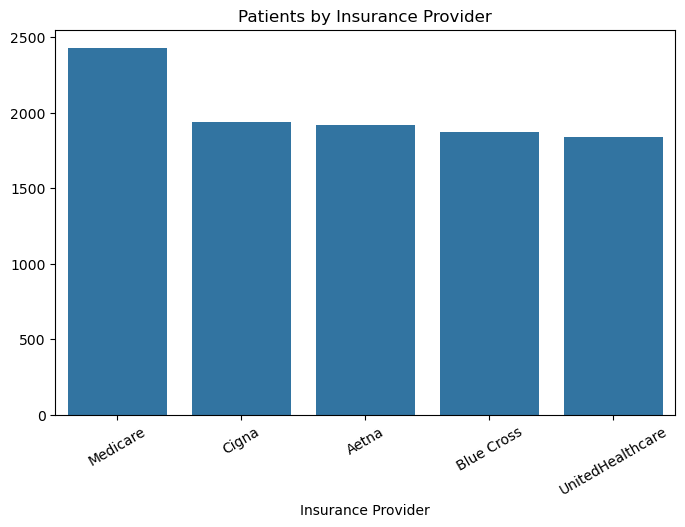

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=insurance.index,
    y=insurance.values
)

plt.xticks(rotation=30)

plt.title("Patients by Insurance Provider")

plt.show()

In [57]:
# Insight: Medicare covers the highest number of patients.

In [37]:
insurance_revenue = (
    df.groupby('Insurance Provider')
    ['Billing Am0unt']
    .sum()
    .sort_values(ascending=False))


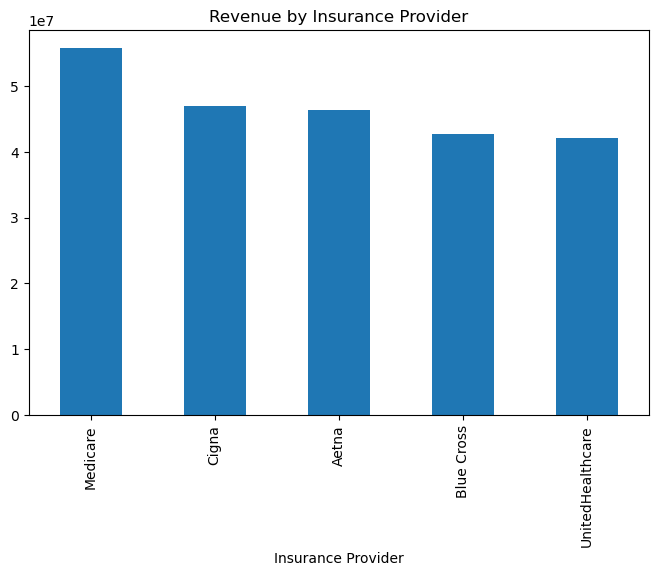

In [38]:
insurance_revenue.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Revenue by Insurance Provider")
plt.show()

In [39]:
admission = (
    df['Admission Type']
    .value_counts()
)


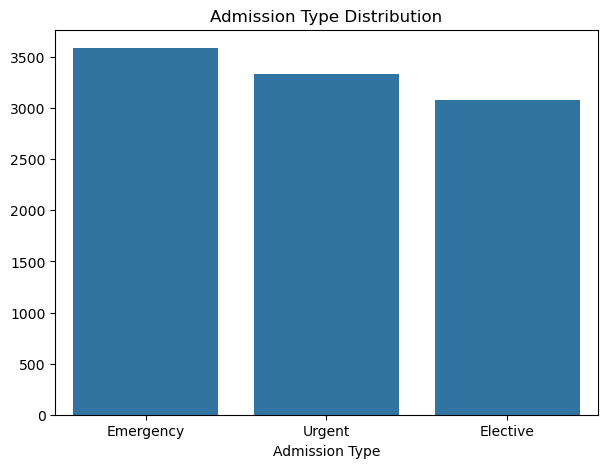

In [40]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=admission.index,
    y=admission.values
)

plt.title("Admission Type Distribution")

plt.show()

In [58]:
# Insight: Emergency admissions are highest.

In [41]:
test_result = (
    df['Test Results']
    .value_counts()
)


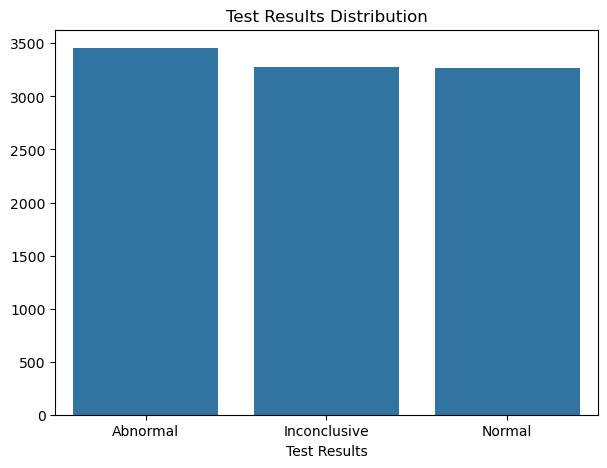

In [42]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=test_result.index,
    y=test_result.values
)

plt.title("Test Results Distribution")

plt.show()

In [59]:
# Insight: Abnormal test results slightly dominate.

In [43]:
top_med = (
    df['Medication']
    .value_counts()
)

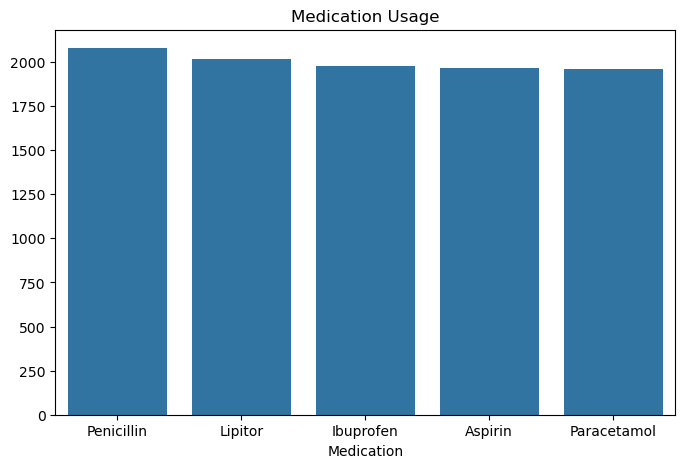

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=top_med.index,
    y=top_med.values
)

plt.title("Medication Usage")

plt.show()

In [60]:
# Insight: Penicillin is the most prescribed medicine.

In [45]:
df['Month'] = (df['Date of Admission'].dt.to_period('M'))

In [46]:
monthly = df.groupby('Month').size()

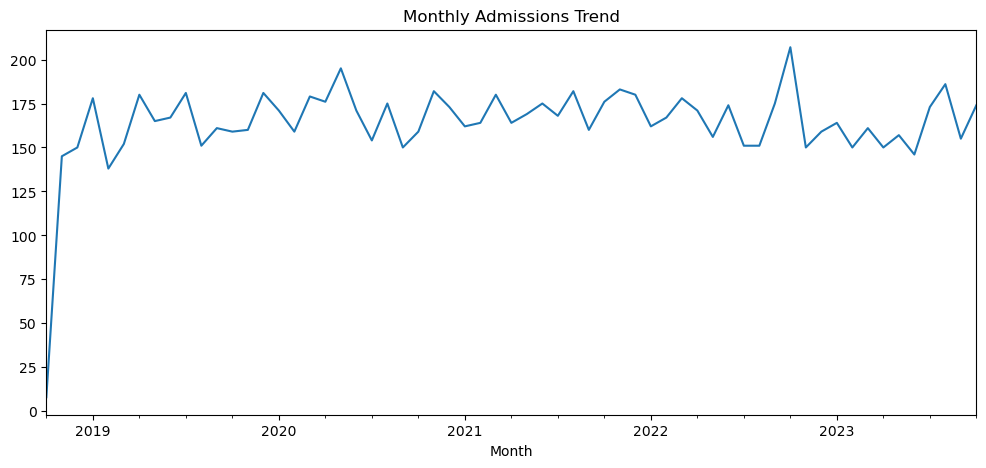

In [47]:
monthly.plot(
    figsize=(12,5)
)

plt.title("Monthly Admissions Trend")

plt.show()

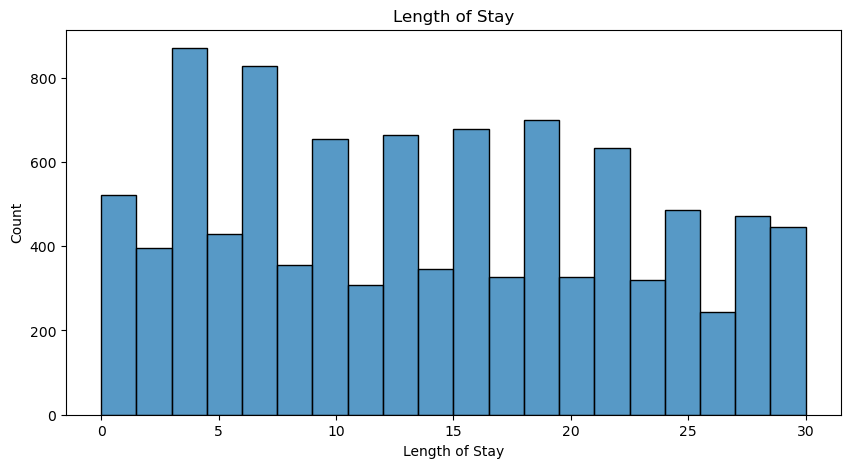

In [48]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Length of Stay'],
    bins=20
)

plt.title("Length of Stay")

plt.show()

In [61]:
# Insight: Average stays 14 days.

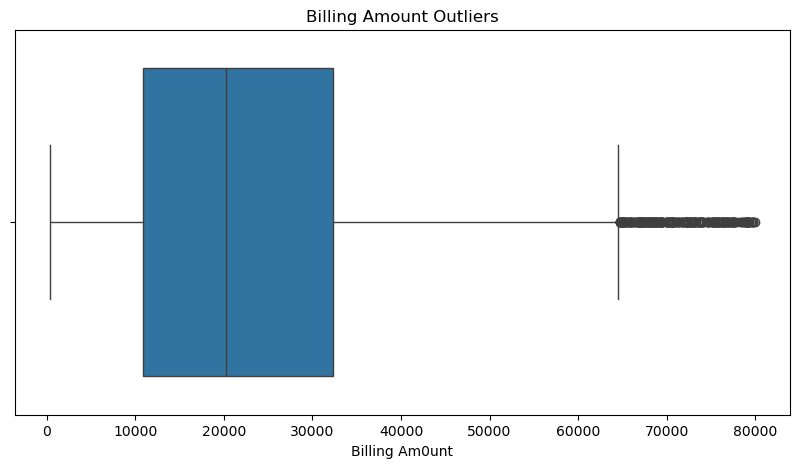

In [51]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['Billing Am0unt']
)

plt.title("Billing Amount Outliers")

plt.show()

In [1]:
# conclusion
# The analysis revealed that hypertension was the most prevalent medical condition,
#emergency admissions were the most common, and Medicare covered the highest number of patients.
#Overall, the project provided valuable insights into patient demographics, healthcare costs, insurance utilization 
# and hospital admission trends, supporting data-driven healthcare decision-making.
